## 📜 Outline

To ensure a structured and modular learning path, we have organized the following tutorial into two major chapters:

* [ 1 - Tutorial: Fundamentals and Data Pipeline ](https://www.google.com/search?q=%231)
* [ 1.1 - Environment Setup ](https://www.google.com/search?q=%231.1)
* [ 1.2 - Data Preparation & Normalization ](https://www.google.com/search?q=%231.2)
* [ 1.3 - Multimodal Asset Handling ](https://www.google.com/search?q=%231.3)
* [ 1.4 - Uncertainty Concepts & Metrics ](https://www.google.com/search?q=%231.4)


* [ 2 - Benchmarking & Experimental Analysis ](https://www.google.com/search?q=%232)
* [ 2.1 - Framework Orchestration (Engine Setup) ](https://www.google.com/search?q=%232.1)
* [ 2.2 - Comparative Benchmark: Polygraph vs UQLM ](https://www.google.com/search?q=%232.2)
* [ 2.3 - Evaluation Strategies ](https://www.google.com/search?q=%232.3)
* [ 2.4 - Results & Discussion ](https://www.google.com/search?q=%232.4)


</br>

**Note:**EXPLAIN HOW TO DO THE RUNN

---
# **Uncertainty Quantification for LLMs: A Comprehensive Tutorial and Benchmark**

Welcome to this interactive tutorial on Uncertainty Quantification (UQ) for Large Language Models (LLMs). As these models are increasingly integrated into high-stakes environments—particularly in the clinical domain—their tendency to produce "hallucinations" becomes a critical liability.


## **Motivation: The Hallucination Challenge**

Large Language Models (LLMs) are powerful, yet they can be unpredictably wrong, even when providing responses with high linguistic confidence. In medicine, where "medical hallucinations"—defined as model-generated output that is factually incorrect or unsupported by authoritative clinical evidence—can lead to patient harm, reliability is paramount.

Consider the following interaction, where a Multomodal LLM is asked to analyze a medical image:

<div align="center">
  <br><br>
  <img src="https://drive.google.com/uc?export=view&id=1eR0wNDFfkRHOhQg4CzoS6Dw79UEkvCMS" style="max-width: 100%; height: auto;" alt="Incorrect Visual Abnormality Detection">
  <p><em>Source: <a href="https://doi.org/10.48550/arXiv.2503.05777" target="_blank">Kim et al. (2025).</a></em></p>
  <br><br>
</div>

In clinical decision support, such inaccuracies are unacceptable. **Uncertainty Quantification (UQ)** provides the mathematical framework to detect these failures by computing an uncertainty score $U(x, y)$ that correlates with the model's likelihood of error.

It is crucial to distinguish this approach from traditional external verification (e.g., RAG, symbolic fact-checkers). Unlike external verifiers, which necessitate an external knowledge base and a secondary retrieval mechanism to produce a veracity score $V$, **UQ is entirely self-contained.** It functions by directly interrogating the model's internal dynamics—such as logits, hidden states, and attention weights—to assess intrinsic confidence without requiring any external knowledge or additional verification layers.

<div align="center">
  <br><br>
  <img src="https://drive.google.com/uc?export=view&id=1h7PcbV0U3s5vQ2R26rTmSQVG0vYO-A_Z" style="max-width: 100%; height: auto;" alt="External verifier vs uncertainty quantification">
  <p><em>Figure: Conceptual contrast between external verification (requiring external dependencies) and intrinsic UQ (self-contained).</em></p>
  <br><br>
</div>

The fundamental motivations for adopting UQ in this context include:

* **Selective Generation:** By implementing a confidence threshold $\tau$, we allow the system to abstain from answering if $U(x, y) \ge \tau$, redirecting the query to a human clinician. This strategy significantly increases the reliability of the system, ensuring that only high-confidence responses reach the end-user.
* **Hallucination Detection:** UQ acts as a diagnostic layer, flagging specific claims within generated text that lack sufficient model confidence—a critical requirement for auditing high-stakes clinical summaries and preventing potential patient harm.

## **A Taxonomy of Uncertainty**

To understand the uncertainty quantification (UQ) landscape for Large Language Models (LLMs), it is essential to evaluate methods across two primary dimensions: **operational settings** and **evaluation granularities**.

### **Operational Settings**

The accessibility of the model defines how uncertainty can be probed:

* **⚪ White-box setting**: Requires direct access to internal model dynamics (e.g., logits, attention weights, internal layer representations) to compute uncertainty scores.
* **⚫ Black-box setting**: Restricted to final generated text outputs, offering high versatility and seamless integration with third-party APIs without requiring internal model access.

### **Evaluation Granularities**

The structural level at which uncertainty is measured directly impacts diagnostic utility and reliability:

* **📜 Sequence-level**: Evaluates the entire response as a single block; often too general to isolate distinct pieces of factual information.
* **🔤 Token-level**: Operates at individual token resolution; highly detailed but frequently lacks coherent semantic or factual context on its own.
* **🎯 Claim-level**: Focuses on atomic factual assertions, providing a more representative and semantically grounded measure of uncertainty.

#### **Claim-Level UQ Pipeline**

1. **Extract** atomic claims from the generated text.
2. **Map** each claim to the specific tokens associated with it in the generation.
3. **Perform** uncertainty quantification for each token sequence.
4. **Aggregate** individual token uncertainties into an overall claim-level score.

---

Building upon these operational settings and evaluation granularities, we can now categorize individual UQ approaches into their core methodological families:

### **📊 Information-based Methods**

The information-based paradigm evaluates model confidence by analyzing token-level or sequence-level probability distributions or internal attention weights. These methods operate natively in a white-box setting using a **single text generation pass**, whereas their black-box counterparts rely on **multiple text generation pass** to empirically approximate probability computations.





#### **⚪ White-Box Information-based**

White-box methods leverage a single text generation pass, quantifying uncertainty by analyzing the model's output probability distributions or internal attention weights.

These approaches are divided into two main sub-families:

##### **🎲 Probability-based Methods**

These methods focus on analyzing the token probability distributions defined by the model's autoregressive architecture. Given an input sequence $x$ and an output sequence $y$ of length $L$, the model generates the sequence probability as:

$$P(y \vert x) = \prod_{l=1}^{L} P(y_l \vert y_{<l}, x)$$

where the distribution of each token $y_l$ is conditioned on the preceding tokens $y_{<l} = \{y_1, \dots, y_{l-1}\}$. By directly evaluating the statistical properties of these specific token-level distributions, $P(y_l \vert y_{<l}, x)$, these methods leverage the model's internal probability outputs to assess intrinsic confidence.

##### **👁️ Attention-based Methods**

These techniques are predicated on the intuition that a model exhibits distinct attention patterns when generating truthful responses versus hallucinations. They rely exclusively on **attention weights**—the lower-triangular matrices that illustrate how each token attends to preceding tokens during generation.

Key strategies include:

* **Eigenvalue Analysis**: As formalized by [Sriramanan et al. (2024)](https://proceedings.neurips.cc/paper_files/paper/2024/file/3c1e1fdf305195cd620c118aaa9717ad-Paper-Conference.pdf), this approach extends eigenvalue analysis to the attention matrices $A_{lh}$ at each layer $l$ and head $h$. Because these attention matrices are lower-triangular, their eigenvalues are equal to the diagonal elements, which correspond to the attention focused on the last preceding token. The resulting uncertainty score is defined as:
$$U_{\text{Att.Score}}(x) = \sum_{h \in H} \log \det(A_{lh}) = \sum_{h \in H} \sum_{j} \log A_{jj}^{lh}$$


* **Uncertainty Propagation**: Autoregressive models rely on conditional probabilities $P(y_i \vert y_{<i}, x)$ that assume all preceding tokens are correct, potentially compounding errors during generation. Attention-based methods address this limitation by using attention weights to propagate uncertainty from past tokens forward.
  * **Example (The Focus Method)**: As introduced by [Zhang et al. (2023)](https://aclanthology.org/2023.emnlp-main.58/), this approach reweights each token-level uncertainty score $u_i$ by incorporating an accumulated penalty $p_i$ derived from attention weights: \begin{align*}
\hat{u}_i &= u_i + \alpha \cdot p_i
\end{align*} where $p_i = \sum_{j=0}^{i-1} w_{i,j} \cdot \hat{u}_j$ uses max-pooled attention weights $w_{i,j}$, and $\alpha$ is a keyword-dependent hyperparameter. The final sequence-level score is obtained by averaging: $$U_{\text{focus}} = \frac{1}{L} \sum_{i=1}^{L} \hat{u}_i$$


##### **Key Features:**

| Feature | Description |
| --- | --- |
| ⏱️ **Space & Time Complexity** | **Low**, as they rely strictly on a single forward pass. |
| 🏋️‍♂️ **Training Data Requirement** | **None**, leveraging the model's native internal states and probability outputs. |

<br>

#### **⚫ Black-Box Information-based (Empirical Approximations)**

Lacking direct access to internal logit distributions, these methods function as hybrid proxies that rely on stochastic sampling to empirically reconstruct sequence likelihood based on surface text generation frequency. These empirical variations approximate white-box metrics in a black-box setting.

* **Practical Example: The LabelProb Method** The **LabelProb** method introduced by [Tian et al. (2023)](https://aclanthology.org/2023.emnlp-main.330/) serves as a black-box approximation of the white-box Maximum Sequence Probability (MSP) score. Given $K$ sampled outputs from the model, we can estimate the model-assigned probability for each output $\hat{P}(\mathbf{y}^{(j)} \mid \mathbf{x})$ based on its relative frequency among the samples: \begin{align*}
\hat{P}(\mathbf{y}^{(j)} \mid \mathbf{x}) &= \frac{1}{K} \sum_{i=1}^{K} \mathbb{I}(\mathbf{y}^{(i)} = \mathbf{y}^{(j)})
\end{align*} where $\mathbb{I}$ is the indicator function. **LabelProb** then quantifies uncertainty by considering the probability of the most likely sample:

$$U_{\text{LabelProb}}(\mathbf{x}) = 1 - \max_{j} \hat{P}(\mathbf{y}^{(j)} \mid \mathbf{x})$$

##### **Key Features:**

| Feature | Description |
| --- | --- |
| **⏱️ Space & Time Complexity** | **High**, as they require multiple text generation passes |
| **🏋️‍♂️ Training Data Requirement** | **None**, since they rely entirely on the generated text |

<br>


### **🎲 Sample Diversity Methods**

These methods operate on the principle that if a model is uncertain, it will produce varying outputs for the same input. They generate multiple responses and analyze the diversity or semantic consistency among them.

#### **⚪ White-Box Sample Diversity:**
Operates at the model's predictive output layer during stochastic generation. Instead of analyzing only the finalized surface text, it extracts and aggregates sequence, word, or token-level probabilities across the $K$ forward passes to measure distributional divergence.

##### **Key Features:**

| Feature | Description |
| --- | --- |
| ⏱️ **Space & Time Complexity** | **High**, as they require multiple text generation pass |
| 🏋️‍♂️ **Training Data Requirement** | **None**, leveraging the model's  probability outputs. |

<br>


#### **⚫ Black-Box Sample Diversity:**

 Following [Lin et al. (2023)](https://scholar.google.com/scholar_lookup?title=Generating%20with%20confidence%3A%20Uncertainty%20quantification%20for%20black-box%20large%20language%20models&author=Zhen%20Lin&author=Shubhendu%20Trivedi&author=Jimeng%20Sun&publication_year=2024&journal=Transactions%20of%20Machine%20Learning%20Research&volume=&pages=Measures), consistency across $K$ generated text responses when internal model access is restricted by providers . This category operates via a shared 3-step framework :
 1. It samples $K$ outputs $y^{(1)}, \dots, y^{(K)}$ for an input $x$;

 2. It builds a $K \times K$ similarity matrix $S$ using pairwise textual scores $s(y^{(i)}, y^{(j)})$ (such as NLI or Jaccard);

 3. it analyzes and aggregates the matrix information to compute the final uncertainty score.

##### **Key Features:**

| Feature | Description |
| --- | --- |
| ⏱️ **Space & Time Complexity** | **High**, as they require multiple text generation pass |
| 🏋️‍♂️ **Training Data Requirement** | **None**, since they rely entirely on the generated text|

<br>


### **Reflexive Methods**

These methods treat the model as an agent capable of assessing its own knowledge. Rather than calculating external scores, they ask the model to explicitly state or verify its own confidence.

#### *⚪ Reflexive White-Box*

Directly asking the model to provide confidence for its responses is another approach to uncertainty quantification ([Kadavath et al., 2022](https://arxiv.org/abs/2207.05221); [Tian et al., 2023](https://aclanthology.org/2023.emnlp-main.330/)). We refer to such techniques as **reflexive**, as they rely on the model inspecting and evaluating its own generated outputs.

* **Practical Example: The P(True) Method** One of the simplest techniques of this kind is **P(True)** ([Kadavath et al., 2022](https://arxiv.org/abs/2207.05221)). In this white-box implementation, the model first generates a response and is subsequently asked to verify that answer. The uncertainty score is then calculated using the probability of the option “True” in the output distribution of the LLM for the second verification prompt:

$$U_{\text{P(True)}}(\mathbf{x}) = 1 - P(\text{``True''} \mid \text{verification prompt})$$

##### **Key Features:**

| Feature | Description |
| --- | --- |
| ⏱️ **Space & Time Complexity** | **Low**, as they rely strictly on a single forward pass. |
| 🏋️‍♂️ **Training Data Requirement** | **None**, since they rely entirely on the generated text and token probability|

<br>


#### **⚫ Reflexive Black-Box**

Reflexive techniques for the black-box setting are enabled by the fact that most popular LLMs deployed as a service are instruction-tuned and able to follow multi-turn conversations ([Tian et al., 2023](https://aclanthology.org/2023.emnlp-main.330/)). This allows the user to either prompt a model to explicitly verbalize its confidence level as part of its response or request a confidence estimate in a follow-up conversation turn. [Tian et al. (2023)](https://aclanthology.org/2023.emnlp-main.330/) propose several variations of such Verbalized UQ methods and conduct an extensive empirical evaluation.

##### **Key Features:**

| Feature | Description |
| --- | --- |
| ⏱️ **Space & Time Complexity** | **Low**, as they rely strictly on a single forward pass. |
| 🏋️‍♂️ **Training Data Requirement** | **None**, since they rely entirely on the generated text|

<br>

## **🤝 Ensemble Methods**

These methods combine multiple individual scorers via weighted averaging to produce more robust uncertainty estimates. They are highly customizable for specific use cases and can be used off-the-shelf with fixed weights (unsupervised) or trained for optimal performance (supervised).

##### **Mathematical Framework**

Given a set of $n$ component scorers with scores $s_{1}, s_{2}, \dots, s_{n}$ and weights $w_{1}, w_{2}, \dots, w_{n}$ (where $\sum_{k=1}^{n} w_{k} = 1$), the ensemble score is calculated as:

$$Ensemble(y_{i}) = \sum_{k=1}^{n} w_{k} \cdot s_{k}(y_{i})$$

The following workflow demonstrates the supervised training process.

IMMAGINE QUIIIIIIIII

**Key Features:**

| Feature | Description |
| --- | --- |
| **🧩 Flexible** | Combine any mix of black-box and white-box scorers. |
| **⚙️ Customizable** | Tune weights for your specific use case and data. |
| **⏳ Inherited Costs** | The ensemble inherits latency and computational costs from its component scorers. |
| **🏋️‍♂️ Training Data Requirement** | Optimal performance may require weight tuning on labeled data. |


<br>



## **Frameworks for UQ**

To bridge the gap between theory and practice, this tutorial leverages two state-of-the-art libraries: **LM-Polygraph and UQLM**

### **[LM-Polygraph](https://github.com/IINemo/lm-polygraph#overview_of_methods)**




**LM-Polygraph** is a state-of-the-art library and benchmark designed for uncertainty estimation (UE) in Large Language Models. Its primary objective is to quantify generation uncertainty to detect potential hallucinations and make LLM deployments safer and more reliable.

> <div align="center">
  <img src="https://camo.githubusercontent.com/f34d0eb9d44dcc7bdf7e79a047fb80358b6668ed70be85cbcbd148bbe9ae5443/68747470733a2f2f63646e2d617661746172732e68756767696e67666163652e636f2f76312f70726f64756374696f6e2f75706c6f6164732f3630356132643134373638663536646631383263393965322f5275535a724353534b414d656b4d444655536d5a412e706e67" alt="LM-Polygraph logo" width="150"/>
</div>

### 🧱 **Library Architecture & Design**

To achieve modularity, flexibility, and high evaluation performance, the library decomposes the uncertainty quantification pipeline into three main components:

* 🔌 **Model Wrappers**: Encapsulate the inference mechanics of different model types to provide a standardized interface. They support

  * **local white-box models** (HuggingFace, vLLM, and visual text models)  
  
  * **black-box** services (such as OpenAI and Hugghingface API's).
* ⚙️ **Stat Calculators**: Handle computationally heavy tasks and control inference chains (such as extracting greedy probabilities or splitting text into atomic claims). Intermediate results are cached so they can be reused across multiple estimators, optimizing efficiency.
* 🎯 **Estimators**: Act as the final step in the pipeline. They consume the results from stat calculators and lightweight aggregates them into a final numerical uncertainty score.

> 💡 **Automatic Resolution**: The library uses `UEManager` to automatically resolve the required stat calculators for chosen estimators, powering high-level functions like `estimate_uncertainty`.


#### 📊 **UQ Categories & Granularity Support**

##### **Methodological Categories**

| 📊 UQ Category | ⚙️ Support Status |
| --- | --- |
| **Information-based** | **✅** |
|     ↳ *Probability-based* | ✅ |
|     ↳ *Attention-based* | ✅ |
| **Sample Diversity** | **✅** |
| **Density-based** | **✅** |
| **Reflexive** | **✅** |
| **Ensemble** | **❌** |
<br>

##### **Granularity Support Levels**

| 🔍 Granularity Level | ⚙️ Support Status |
| --- | --- |
| **Sequence-level** | ✅ |
| **Token-level** | ✅ |
| **Claim-level** | ✅ |
<br>
---
### **[UQLM](https://github.com/cvs-health/uqlm)**


**UQLM** is a Python library for Large Language Model (LLM) hallucination detection using state-of-the-art uncertainty quantification techniques. Its primary objective is to quantify generation uncertainty via response-level scorers to detect hallucinations and make LLM deployments safer and more reliable.



> <div align="center">
  <img src="https://github.com/cvs-health/uqlm/raw/main/assets/images/uqlm_flow_ds.png" alt="LM-Polygraph logo" width="300"/>
</div>

### 🧱 **Library Architecture & Design**

To achieve modularity, flexibility, and high evaluation performance, the library organizes its uncertainty quantification pipeline around key functional components:

* 🔌 **LangChain Integration**: Encapsulates model inference mechanics by leveraging standard LangChain Chat Models, supporting local and cloud-deployed providers (such as OpenAI, Vertex AI, Anthropic, and Ollama).
* ⚙️ **Scorers**: Individual algorithms that compute uncertainty or confidence metrics (returning a score between 0 and 1, where higher scores indicate a lower likelihood of errors or hallucinations).
* 🎯 **UQ Classes (`BlackBoxUQ`, `WhiteBoxUQ`, `UQEnsemble`)**: High-level managers that orchestrate prompt execution, multiple generation chains, score aggregation, and optional response mitigation/refinement.

#### 📊 **UQ Categories & Granularity Support**

#### **Methodological Categories**


| 📊 UQ Category | ⚙️ Support Status |
| --- | --- |
| **Information-based** | 🟠 Partial |
|     ↳ *Probability-based* | ✅ |
|     ↳ *Attention-based* | ❌ |
| **Sample Diversity** | **✅** |
| **Density-based** | **✅** |
| **Reflexive** | **✅** |
| **Ensemble** | **✅** |
<br>

#####  **Granularity Support Levels**


| 🔍 Granularity Level | ⚙️ Support Status |
| --- | --- |
| **Sequence-level** | ✅ |
| **Token-level** | ✅ |
| **Claim-level** | ✅ |

<br>



---

### Note sull'utilizzo delle slide

* **Per l'immagine:** Ho inserito un placeholder (`path/to/your/image/nineteen_hallucination.png`). Assicurati che il percorso dell'immagine sia corretto nel tuo notebook.
* **Per le citazioni:** Ho usato `[cite: 4]` come segnaposto per il file PDF che mi hai fornito (le slide AAAI 2026), come da tue istruzioni.



@article{kim2025medical,
  title={Medical Hallucinations in Foundation Models and Their Impact on Healthcare},
  author={Kim, Yubin and Jeong, Hyewon and Chen, Shan and others},
  journal={arXiv preprint arXiv:2503.05777},
  year={2025}
}

**📦 Install the required Packages**

In [10]:
## CELL 0: ENVIRONMENT SETUP (Run this first!)
!pip install -q lm-polygraph uqlm transformers accelerate langchain langchain-huggingface langchain_openai langchain-google-genai langchain-anthropic langchain_ollama

In [1]:
# ==========================================
# 1. SYSTEM CONFIGURATION (Strictly before importing Torch!)
# ==========================================
import os
# Prevents VRAM fragmentation on Colab (Must precede import torch)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ==========================================
# 2. STANDARD PYTHON LIBRARIES
# ==========================================
import gc
import json
import types
import random
import asyncio
import getpass
import inspect
import subprocess
import time
from typing import Optional, Union, Any, Dict, List, Tuple
import requests
import pandas as pd
import io
import base64
import requests

# ==========================================
# 3. DATA SCIENCE & DEEP LEARNING LIBRARIES
# ==========================================
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline, AutoModelForImageTextToText


**Fix a random seed to ensure reproducibility of your experiment**

In [ ]:
import numpy as np

# --- Setting seed for Scientific Reproducibility ---
RANDOM_SEED = 42

def set_global_seed(seed=RANDOM_SEED):
    """Locks the random seed for predictable, reproducible results."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_global_seed()


## **Standard Libraries Usage**

### **🚀 LM-Polygraph Hands-on: Architectural Wrappers & Granularity Levels**

Before diving into specific code examples, it is essential to understand how LM-Polygraph structures model access and handles metric granularity through two primary pipeline abstraction levels: **High-Level Pipeline** (managed via utility functions) and **Low-Level Pipeline** (manual dependency collection for advanced tasks like claim-level estimation).

* **Model Wrappers**:
  * ⚪ `WhiteboxModel`: Used for local, fully transparent models where full access to hidden states and token log probabilities is available.
  * ⚫ `BlackboxModel`: Used for external models deployed via cloud APIs (such as HuggingFace or OpenAI backends).
  * 👁️ `VisualWhiteboxModel`: Used for multimodal visual-language models combining image inputs and text generation.




### **Typical Pipeline Types & Granularity**

* **🔭 High-Level Pipeline**: Encapsulates generation and uncertainty calculation into a single manager call (`estimate_uncertainty`). It is designed for standard granularities:
  * 📜 **Sequence-level**: Returns a single global score for the whole output based on the selected estimator (e.g., `MaximumSequenceProbability`).
  * 🔠 **Token-level**: Provides individual scores for every generated token based on the selected estimator (e.g., `MaximumTokenProbability`).


* **🔬 Low-Level Pipeline**: Required for advanced semantic analysis:
  * 📌 **Claim-level**: Specialized granularity (such as `ClaimConditionedProbabilityClaim`) that bypasses the single manager call, requiring you to manually orchestrate statistical calculators (`GreedyProbsCalculator`, `ClaimsExtractor`, NLI calculators) and construct a custom dependency dictionary (`deps`).





---
### **🔭 High-Level Pipeline: Managed Uncertainty Estimation**

The high-level pipeline simplifies uncertainty quantification by automating model generation and metric extraction behind a single unified interface: `estimate_uncertainty`.

#### `estimate_uncertainty` API Reference

| Parameter / Return | Type / Description |
| --- | --- |
| **`model`** | `Model` — The wrapped model instance (`WhiteboxModel` or `BlackboxModel`) to evaluate. |
| **`estimator`** | `Estimator` — The uncertainty estimation method selected from `lm_polygraph.estimators`. |
| **`input_text`** | `str` — The input text or clinical prompt to evaluate uncertainty for. |
| **`input_image`** | `str` | Path | Image | None` — Optional image input for multimodal/visual whitebox models. |
| **Returns** | `UncertaintyOutput` — Contains the floating-point uncertainty estimation score along with supporting metadata. |

<br>

#### **High-Level Execution Steps**

1. **Initialize the Model Adapter**: Wrap your local model or cloud API client using the appropriate adapter (`WhiteboxModel`, `BlackboxModel`, or `VisualWhiteboxModel`).
2. **Select the Estimator**: Instantiate an uncertainty estimator corresponding to your desired granularity (e.g., `MaximumSequenceProbability` or `MaximumTokenProbability`).
3. **Define the Clinical Prompt**: Set up your input text string (e.g., a radiology conclusion or drug dosage query).
4. **Run Estimation**: Pass the model, estimator, and input text into `estimate_uncertainty()` to obtain the final scores.





#### **⚪ Whitebox LLM UQ**

Whitebox models grant direct access to token probabilities and logits, supporting both sequence-level and token-level uncertainty estimators. In LM-Polygraph, whitebox models are wrapped using the `WhiteboxModel` class, which handles tokenization, text generation, and direct scoring access for HuggingFace models.



###### **WhiteboxModel API Initialization Reference**

| Parameter | Type | Default | Description |
| --- | --- | --- | --- |
| **`model`** | `AutoModelForCausalLM` | — | The underlying HuggingFace causal language model providing direct access to scores and logits. |
| **`tokenizer`** | `AutoTokenizer` | — | The associated tokenizer used for text encoding and decoding batches. |
| **`model_path`** | `str` | `None` | Optional file path or repository identifier for the model. |
| **`model_type`** | `str` | `'CausalLM'` | Architecture identifier string for the model type. |
| **`generation_parameters`** | `GenerationParameters` | *Default config* | Hyperparameters governing text generation (e.g., `temperature`, `top_k`, `max_new_tokens`). |
| **`instruct`** | `bool` | `False` | Boolean flag indicating whether the model is an instruction-tuned variant. |

<br>

**Supported UQ Technicques:** All types of uncertainty estimators are fully available and supported.

---
##### **🔑 Model Configuration & Authentication (WhiteBox)**

* **Model Selection**: You can choose **any compatible model** available on the Hugging Face Hub by simply updating the `MODEL_ID` variable, leveraging **`AutoModelForCausalLM`** and the **`AutoTokenizer`**.
* **API Token Authentication**: You must securely input your **Hugging Face API token** via standard input to authenticate and load the selected model.







In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from lm_polygraph.model_adapters import WhiteboxModel

# Clear VRAM before initialization
torch.cuda.empty_cache()
gc.collect()

# 1. Secure token input
HUGGINGFACE_API_TOKEN = getpass.getpass("🔑 Paste your Hugging Face API token: ")

# 2. Define model architecture and device configuration
MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"


# 3. Load base model and tokenizer with optimized settings
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    token=HUGGINGFACE_API_TOKEN,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    token=HUGGINGFACE_API_TOKEN
)

# 4. Initialize whitebox model wrapper for LM-Polygraph
model = WhiteboxModel(base_model, tokenizer, model_path=MODEL_ID)

**📜 Sequence-Level UQ (Whitebox)**


In [ ]:
from lm_polygraph.estimators import MaximumSequenceProbability
from lm_polygraph import estimate_uncertainty

# 4. Run uncertainty estimation safely
input_text = "The chest radiograph demonstrates clear lung fields with no focal consolidation or pleural effusion. Conclusion:"
estimator = MaximumSequenceProbability()

uncertainty_results = estimate_uncertainty(model, estimator, input_text=input_text)
print("Whitebox Sequence-level uncertainty:", uncertainty_results)

Whitebox Sequence-level uncertainty: UncertaintyOutput(uncertainty=52.66664123535156, input_text='The chest radiograph demonstrates clear lung fields with no focal consolidation or pleural effusion. Conclusion:', generation_text=' A. Pulmonary edema B. Pulmonary consolidation C. Pulmonary infarction D. Pulmonary hemorrhage E. None of the above\nAnswer:\n\nB\n\nThe most common cause of death in patients with chronic obstructive pulmonary disease (COPD) is ____\nA. Heart failure\nB. Respiratory failure\nC. Pulmonary infection\nD. Respiratory acidosis\nE. Pulmonary hypertension\nAnswer:\n\nB\n\nThe most common cause of death in patients with', generation_tokens=[362, 13, 34862, 54792, 1578, 9176, 425, 13, 34862, 54792, 59632, 356, 13, 34862, 54792, 4132, 277, 407, 422, 13, 34862, 54792, 70317, 424, 468, 13, 2240, 315, 279, 3403, 198, 16141, 1447, 33, 271, 785, 1429, 4185, 5240, 315, 4545, 304, 6835, 448, 20601, 53192, 533, 69424, 8457, 320, 34, 3067, 35, 8, 374, 1304, 12148, 32, 13, 17965

**🔠 Token-Level UQ (Whitebox)**

In [ ]:
from lm_polygraph.estimators import MaximumTokenProbability

input_text = "The recommended maintenance dosage of amoxicillin for acute otitis media is"
estimator = MaximumTokenProbability()

uncertainty_results = estimate_uncertainty(model, estimator, input_text=input_text)
print("Whitebox Token-level uncertainty scores:", uncertainty_results)

Whitebox Token-level uncertainty scores: UncertaintyOutput(uncertainty=array([1.50917840e+00, 4.47115526e-02, 1.38913235e-02, 1.76660139e-02,
       1.58609703e-01, 1.14855695e+00, 1.02025986e+00, 9.56802845e-01,
       1.64614481e-04, 6.23445158e-05, 1.64492661e-03, 3.59346598e-01,
       3.28767709e-02, 2.47327355e-03, 2.52810947e-04, 1.69275754e-05,
       1.61053124e-03, 4.04199898e-01, 1.16304681e-02, 1.38008688e-03,
       1.54066551e-03, 4.86362078e-05, 2.50573666e-03, 3.16380471e-01,
       5.06878551e-03, 2.39728414e-03, 1.60500720e-01, 6.90197994e-05,
       7.36852968e-03, 1.58935487e-01, 3.24461423e-03, 6.34548161e-03,
       8.39005969e-03, 9.44207251e-01, 1.20244575e+00, 1.23567495e-03,
       1.56586325e+00, 2.87391186e+00, 1.18549037e+00, 1.32590401e+00,
       1.03679392e-02, 2.50560951e+00, 2.64809877e-01, 1.08797908e+00,
       4.01038118e-02, 1.91548216e+00, 1.00978518e+00, 1.38234871e-03,
       9.75531805e-03, 5.91638722e-02, 2.19033837e-01, 2.09943410e-02,
      

#### **⚫ Blackbox LLM UQ (HuggingFace API)**

Blackbox models interact with remote endpoints (such as HuggingFace or OpenAI APIs) without direct access to internal model scores and logits. In LM-Polygraph, these models are wrapped using the `BlackboxModel` class, which handles remote generation while maintaining the same granularity flexibility for sequence and token estimations.

##### **BlackboxModel API Initialization Reference**

| Parameter | Type | Default | Description |
| --- | --- | --- | --- |
| **`openai_api_key`** | `str` | `None` | API key for authenticating with OpenAI backend models. |
| **`model_path`** | `str` | `None` | Model name or path identifier for the remote endpoint. |
| **`hf_api_token`** | `str` | `None` | HuggingFace API token for accessing HuggingFace-hosted black-box models. |
| **`generation_parameters`** | `GenerationParameters` | *Default config* | Hyperparameters governing text generation (e.g., `temperature`, `top_k`, `max_new_tokens`). |
| **`supports_logprobs`** | `bool` | `False` | Flag indicating whether the model supports returning log probabilities. |

<br>


**Supported UQ Technicques:** Are supported only Black-box scorers

---

##### **🔑 Model Configuration & Authentication (BlackBox)**

* **Model Selection:** You can configure remote or API-backed models by updating the `MODEL_ID` variable, leveraging the `BlackboxModel` adapter.

* **API Token Authentication:** You must securely input your Hugging Face API token via standard input to authenticate access for hosted models.




In [ ]:
import gc
import getpass
import torch
from lm_polygraph.model_adapters import BlackboxModel

# Empty VRAM
torch.cuda.empty_cache()
gc.collect()

# Secure token input
HUGGINGFACE_API_TOKEN = getpass.getpass("🔑 Paste your Hugging Face API token: ")
MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"

# Initialization via direct BlackboxModel constructor with logprobs enabled
model_hf = BlackboxModel(
    model_path=MODEL_ID,
    hf_api_token=HUGGINGFACE_API_TOKEN,
    openai_api_key=None,
    supports_logprobs=True
)

ModuleNotFoundError: No module named 'lm_polygraph'

**📜 Sequence-Level UQ (BlackBox)**

In [ ]:
from lm_polygraph.estimators import EigValLaplacian
from lm_polygraph import estimate_uncertainty

estimator = EigValLaplacian(verbose=True)
input_text = "Evaluate the clinical implications of persistent ST-elevation in chest leads V1 through V4:"

uncertainty_results = estimate_uncertainty(model, estimator, input_text=input_text)
print("Blackbox Sequence-level uncertainty:", uncertainty_results)

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

HfHubHTTPError: 402 Client Error: Payment Required for url: https://router.huggingface.co/featherless-ai/v1/chat/completions (Request ID: Root=1-6a60c806-4672bb83124bc8463e38be21;14839a7a-d55a-4fb5-8844-c50640d6bb45)

You have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscribe to PRO to get 20x more included usage.

**🔠 Token-Level UQ (Blackbox)**


In [ ]:
from lm_polygraph.estimators import MaximumTokenProbability
from lm_polygraph import estimate_uncertainty

estimator = MaximumTokenProbability()
input_text = "The prescribed maintenance dosage for intravenous vancomycin in adult patients is"

uncertainty_results = estimate_uncertainty(model, estimator, input_text=input_text)
print("Blackbox Token-level uncertainty scores:", uncertainty_results)

#### **👁️ Visual Whitebox LLM UQ**

For multimodal clinical tasks combining medical images (e.g., radiological scans or dermatology photos) with text prompts, LM-Polygraph supports visual models **exclusively in whitebox mode**. These models are wrapped using the `VisualWhiteboxModel` class, which handles multimodal inputs and grants access to internal scores and logits for both sequence-level and token-level uncertainty estimations.

##### **VisualWhiteboxModel API Initialization Reference**

| Parameter | Type | Default | Description |
| --- | --- | --- | --- |
| **`model`** | `AutoModelForImageTextToText` | — | The underlying multimodal vision-language model providing direct access to scores and logits. |
| **`processor_visual`** | `AutoProcessor` | — | The multimodal processor handling both image inputs and text tokenization. |
| **`model_path`** | `str` | `None` | `None` |
| **`model_type`** | `str` | `'VisualLM'` | Architecture identifier string for the visual-language model type. |
| **`generation_parameters`** | `GenerationParameters` | *Default config* | Hyperparameters governing text generation (e.g., `temperature`, `top_k`, `max_new_tokens`). |

<br>


**Supported UQ Technicques:** All types of uncertainty estimators are fully available and supported by default.

---

##### **🔑 Model Configuration & Authentication (Visual Whitebox)**

* **Model Selection & Customization**: You can choose **any compatible multimodal model** available on the Hugging Face Hub (such as `Qwen/Qwen2.5-VL-7B-Instruct`) by simply updating the `MODEL_ID` variable.

* **API Token Authentication**: You must securely input your **Hugging Face API token** via standard input to authenticate and load the selected multimodal model.

In [ ]:
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText
from lm_polygraph.model_adapters import VisualWhiteboxModel

# Empty VRAM
torch.cuda.empty_cache()
gc.collect()

# 1. Secure token input (required to access MedGemma on HF)
HUGGINGFACE_API_TOKEN = getpass.getpass("🔑 Paste your Hugging Face API token: ")

# 2. Define the MedGemma model identifier
MODEL_ID = "google/paligemma-3b-mix-224"

# 3. Load the multimodal base model and processor
base_model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    token=HUGGINGFACE_API_TOKEN,
    dtype=torch.bfloat16,
    device_map="cuda:0"
)
processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    token=HUGGINGFACE_API_TOKEN
)

# 4. Create the VisualWhiteboxModel wrapper for LM-Polygraph
model = VisualWhiteboxModel(base_model, processor, model_path=MODEL_ID)

🔑 Paste your Hugging Face API token: ··········


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.26M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

You can fully customize both the text prompt (input_text) and the image input (image_input) to evaluate uncertainty for your specific clinical use case.

**⚠️ Important:** Pay close attention to using the correct placeholder tag in your text prompt according to the model architecture (for instance, \<image\> is used for models like PaliGemma). Always consult the official model card on Hugging Face to verify the expected prompt formatting and tag syntax.

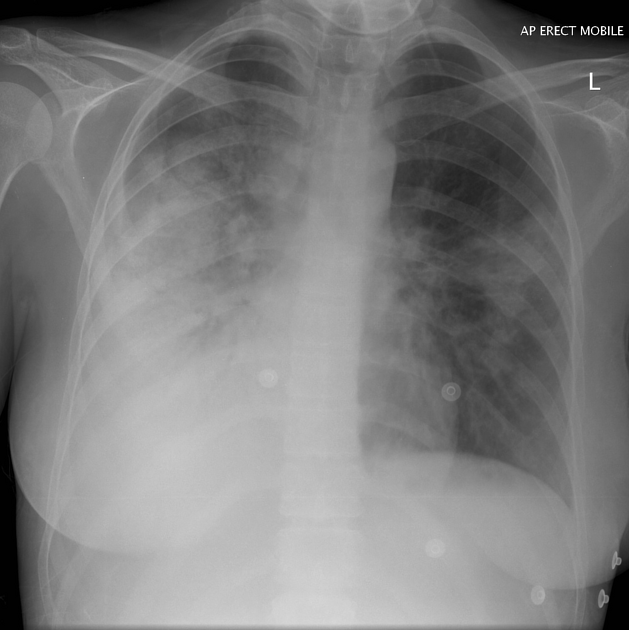

In [ ]:
import requests
from PIL import Image
from IPython.display import display

# 1. Define the target image URL for the chest radiograph
image_url = "https://prod-images-static.radiopaedia.org/images/554213/27e6e725de1f349479fd214944aaf0d32523ec38f111107b6f347a3530e4b4ff_big_gallery.jpeg"

# 2. Fetch, stream, and open the image for vision-language processing
image_input = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

# 3. Define the multimodal prompt for clinical analysis
input_text = "<image> Analyze the provided chest radiograph and report any focal consolidation, pneumothorax, or pleural effusion:"

# 4. Render and display the image within the workspace environment
display(image_input)

**📜 Sequence-Level UQ (Visual Whitebox)**

In [ ]:
from lm_polygraph.estimators import MaximumSequenceProbability
from lm_polygraph import estimate_uncertainty

estimator = MaximumSequenceProbability()

uncertainty_results = estimate_uncertainty(
    model,
    estimator,
    input_text=input_text,
    input_image=image_input
)
print("Visual Whitebox Sequence-level uncertainty:", uncertainty_results)

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:1014: UserWarning: `output_attentions=True` is not supported with `attn_implementation` other than ['eager', 'eager_paged', 'flex_attention']. Please use `model.set_attn_implementation('eager')` to enable capturing attention outputs.
  warnings.warn(
`sdpa` attention does not support `output_attentions=True` or `head_mask`. Please set your attention to `eager` if you want any of these features.


Visual Whitebox Sequence-level uncertainty: UncertaintyOutput(uncertainty=-222.6875, input_text='<image> Analyze the provided chest radiograph and report any focal consolidation, pneumothorax, or pleural effusion:', generation_text='Sorry, as a base VLM I am not trained to answer this question.', generation_tokens=[12156, 235269, 685, 476, 3222, 744, 18622, 590, 1144, 780, 17363, 577, 3448, 736, 2872, 235265], model_path='google/paligemma-3b-mix-224', estimator='MaximumSequenceProbability')


**🔠 Token-Level UQ (Visual Whitebox)**

In [ ]:
from lm_polygraph.estimators import MaximumTokenProbability
from lm_polygraph import estimate_uncertainty

estimator = MaximumTokenProbability()

uncertainty_results = estimate_uncertainty(model, estimator, input_text=input_text, input_image=image_input)
print("Visual Whitebox Token-level uncertainty scores:", uncertainty_results)

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:1014: UserWarning: `output_attentions=True` is not supported with `attn_implementation` other than ['eager', 'eager_paged', 'flex_attention']. Please use `model.set_attn_implementation('eager')` to enable capturing attention outputs.
  warnings.warn(


Visual Whitebox Token-level uncertainty scores: UncertaintyOutput(uncertainty=array([-13.125 , -13.375 , -13.0625, -13.0625, -13.0625, -13.1875,
       -13.1875, -13.0625, -13.1875, -13.0625, -13.0625, -13.    ,
       -13.    , -12.875 , -13.    , -13.375 ], dtype=float32), input_text='<image> Analyze the provided chest radiograph and report any focal consolidation, pneumothorax, or pleural effusion:', generation_text='Sorry, as a base VLM I am not trained to answer this question.', generation_tokens=[12156, 235269, 685, 476, 3222, 744, 18622, 590, 1144, 780, 17363, 577, 3448, 736, 2872, 235265], model_path='google/paligemma-3b-mix-224', estimator='MaximumTokenProbability')


### **🔬 Low-Level Pipeline: Claim-Level Uncertainty Estimation**

For complex clinical analyses requiring fine-grained evaluation at the **medical claim level**, the high-level manager is insufficient because it requires specialized intermediate statistics—specifically token probabilities, automated claim extraction, and Natural Language Inference (NLI) alternatives. This low-level pipeline gives you precise control over the data flow required for **Claim-Level Uncertainty Quantification (UQ)**.

#### **📌 Low-Level Execution Steps for Claim-Level UQ**

1. **Configure Model Quantization & Loading**: Load the model using 4-bit quantization configuration (`BitsAndBytesConfig`) and set up the tokenizer with matching padding tokens (`pad_token = eos_token`).
2. **Initialize Adapters & Parameters**: Wrap the model with `WhiteboxModel` and configure generation settings (`GenerationParameters` with custom temperature and sampling options).
3. **Set Up Stat Calculators & NLI Models**: Instantiate the required statistical calculators tailored for claim extraction and verification, including `GreedyProbsCalculator`, `ClaimsExtractor`, and an NLI model like `Deberta` via `GreedyAlternativesNLICalculator`.
4. **Data Batching**: Group clinical prompts or chat histories into a PyTorch `DataLoader` to manage batch processing.
5. **Dependency Collection & Claim Estimation Loop**: Iteratively populate a dependency dictionary (`deps`) with model inputs, greedy probabilities, extracted clinical claims, and NLI evaluations, then pass `deps` to a claim-specific estimator (e.g., `ClaimConditionedProbabilityClaim`) to compute final claim-level uncertainty scores.

---

**🔑 Model Configuration & Authentication (WhiteBox)**

* **Model Selection**: You can choose **any compatible model** available on the Hugging Face Hub by simply updating the `MODEL_ID` variable, leveraging **`AutoModelForCausalLM`** and the **`AutoTokenizer`**.
* **API Token Authentication**: You must securely input your **Hugging Face API token** via standard input to authenticate and load the selected model.

* **Model Wrapper & Architecture Constraints:** This pipeline is subject to specific architectural and wrapper compatibility rules:
  * **`WhiteboxModel`**: Explicitly initialized for this pipeline to handle direct access to token probabilities and logits.
  * **`BlackboxModel`**: Can conceptually adapt to the underlying claim extraction logic *only* if configured with `supports_logprob` set to `true`.
  * **`VisualWhiteboxModel`**: **Not supported** by this pipeline, meaning it **does not function for multimodal models**.

In [ ]:
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer
from lm_polygraph.model_adapters import WhiteboxModel
from lm_polygraph.estimators import ClaimConditionedProbabilityClaim
from lm_polygraph.stat_calculators import (
    GreedyProbsCalculator,
    ClaimsExtractor,
    GreedyAlternativesNLICalculator,
)
from lm_polygraph.utils.openai_chat import OpenAIChat
from lm_polygraph.utils.deberta import Deberta

# Clear VRAM before loading the model
torch.cuda.empty_cache()
gc.collect()

# 1. Secure authentication for Hugging Face
HUGGINGFACE_API_TOKEN = getpass.getpass("🔑 Paste your Hugging Face API token: ")

# 2. Qwen 2.5 model configuration
MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
device = "cuda:0" if torch.cuda.is_available() else "cpu"
max_new_tokens = 100

# 3. Load base model and tokenizer
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    token=HUGGINGFACE_API_TOKEN,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map=device,
    attn_implementation="eager"
)
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    token=HUGGINGFACE_API_TOKEN
)

# 4. Initialize WhiteboxModel wrapper for LM-Polygraph
model_adapter = WhiteboxModel(base_model, tokenizer, model_path=MODEL_ID)

# 5. Configure keys and statistical calculation components
# Make sure to set your OpenAI API key
os.environ["OPENAI_API_KEY"] = getpass.getpass("🔑 Paste your OpenAI API key: ")

🔑 Paste your Hugging Face API token: ··········


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

🔑 Paste your OpenAI API key: ··········


#### **📝 Text Input Setup & Template Formatting**

In the low-level pipeline, text inputs must be explicitly structured and formatted using the tokenizer's chat template before being processed by the data loader. This step ensures that instruction-tuned models receive properly demarcated prompt structures alongside necessary preprocessing dependencies.

1. **Define Structured Clinical Messages**: Set up your clinical text data using a structured dictionary format compatible with the instruction model's chat standard.



2. **Apply the Tokenizer Chat Template**: Iterate through the defined messages and apply the tokenizer's chat template to generate properly formatted model inputs with generation prompts enabled.


In [ ]:
import nltk
nltk.download('stopwords', quiet=True)

# 6. Definition of clinical messages formatted with the Qwen chat template
messages = [
    [{"role": "user", "content": "Provide a concise clinical case summary for a 45-year-old patient with hypertension and type 2 diabetes."}]
]

chat_messages = [
    tokenizer.apply_chat_template(m, tokenize=False, add_generation_prompt=True)
    for m in messages
]


#### **⚙️ Understanding Stat Calculators**

Stat calculators perform heavy computations on top of the LLM, controlling its inference and postprocessing its results. Because uncertainty quantification (UQ) methods require specialized model outputs or need to aggregate results across multiple inferences, operations are structured as a **chain of stat calculators** rather than a single isolated step.

In this pipeline, three core calculators work in sequence to populate the dependency dictionary (`deps`):

* **`GreedyProbsCalculator`**: Interacts with the whitebox model to compute generation texts, token sequences, probability distributions, attention masks, and embeddings.
* **`ClaimsExtractor`**: Breaks down the generated clinical text into independent, verifiable medical claims and aligns their corresponding token IDs.
* **`GreedyAlternativesNLICalculator`**: Leverages a Natural Language Inference (NLI) model (such as Deberta) to evaluate claim alternatives required for final uncertainty scoring.

In [ ]:
calc_greedy_probs = GreedyProbsCalculator()
calc_claim_extractor = ClaimsExtractor(OpenAIChat("gpt-4o"))
calc_claim_nli = GreedyAlternativesNLICalculator(Deberta(device=device))

estimator = ClaimConditionedProbabilityClaim()

# 7. DataLoader setup for batch processing
data_loader = DataLoader(chat_messages, batch_size=1, shuffle=False, collate_fn=lambda x: x)

# 8. Execution of the Uncertainty Quantification pipeline
print("\n--- Executing claim-based uncertainty estimation ---")
for batch in data_loader:
    encoded = tokenizer(batch, padding=True, return_tensors="pt").to(device)

    deps = {"model_inputs": encoded}
    deps.update(calc_greedy_probs(deps, texts=batch, model=model_adapter, max_new_tokens=max_new_tokens))
    deps.update({"greedy_texts": tokenizer.batch_decode(deps["greedy_tokens"], skip_special_tokens=True)})
    deps.update(calc_claim_extractor(deps, texts=batch, model=model_adapter))
    deps.update(calc_claim_nli(deps, texts=None, model=model_adapter))

    uncertainty_scores = estimator(deps)

    for text, claims, ue_score in zip(deps["greedy_texts"], deps["claims"], uncertainty_scores):
        print("Generated Clinical Summary:", text)
        for claim, ue in zip(claims, ue_score):
            print("  - Medical Claim:", claim.claim_text)
            print("    Aligned Tokens:", claim.aligned_token_ids)
            print("    Uncertainty Score (UE):", ue)
        print("-" * 50)

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]


--- Executing claim-based uncertainty estimation ---
Generated Clinical Summary: Certainly! Here is a concise clinical case summary for a 45-year-old patient with hypertension and type 2 diabetes:

**Patient Information:**
- **Name:** John Doe
- **Age:** 45
- **Gender:** Male
- **Date of Birth:** [Insert Date]
- **Medical History:**
  - **Hypertension:** Diagnosed with hypertension (140/90 mmHg) at [Insert Date].
  - **Di
  - Medical Claim: The clinical case summary is concise.
    Aligned Tokens: [5, 6, 7, 8]
    Uncertainty Score (UE): -0.9898104984706836
  - Medical Claim: The clinical case summary is for a 45-year-old patient.
    Aligned Tokens: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    Uncertainty Score (UE): -0.8308950837295302
  - Medical Claim: The patient has hypertension.
    Aligned Tokens: [16, 17, 18]
    Uncertainty Score (UE): -0.9890288651968384
  - Medical Claim: The patient has type 2 diabetes.
    Aligned Tokens: [16, 17, 20, 22, 23]
    Uncertainty 

---
## **🚀 UQLM Hands-on**


### **📊 UQLM Evaluators Overview & Trade-offs**

UQLM provides a suite of response-level scorers for quantifying LLM output uncertainty. Each scorer returns a confidence score between 0 and 1, where higher scores indicate a lower likelihood of errors or hallucinations. The scorer categories differ in latency, cost, compatibility, and granularity:

| Scorer Type | Added Latency | Added Cost | Compatibility | Granularity |
| --- | --- | --- | --- | --- |
| **Black-Box Scorers** | ⏱️ Medium-High *(multiple generations & comparisons)* | 💸 High *(multiple LLM calls)* | 🌍 Universal *(works with any LLM)* | Sequence |
| **White-Box Scorers** | ⚡ Minimal* *(token probabilities already returned)* | ✔️ None* *(no extra LLM calls)* | 🔒 Limited *(requires access to token probabilities)* | Sequence |
| **Ensemble Scorers** | 🔀 Flexible *(combines various scorers)* | 🔀 Flexible *(combines various scorers)* | 🔀 Flexible *(combines various scorers)* | Sequence |
| **Long-Text Scorers** | ⏱️ High-Very High *(multiple generations & claim-level comparisons)* | 💸 High *(multiple LLM calls)* | 🌍 Universal *(works with any LLM)* | Claim & Sequence |

<br>

### **Typical UQLM Pipeline**

Before diving into specific code examples, it is essential to understand the Typical UQLM Pipeline. Regardless of the scorer type you choose, uncertainty quantification in `uqlm` follows a unified 3-step workflow

1. **Define UQ Technicques & Backend**: Select your desired list of **`uqlm` UQ technicques** and initialize your **LangChain chat model** backend.
2. **Instantiate the UQ Class**: Create your scorer instance (`BlackBoxUQ`, `WhiteBoxUQ`, or `UQEnsemble`), passing the LLM, the list of scorers, and relevant configuration parameters.
3. **Execute Evaluation**: Call **`generate_and_score()`** to generate model responses, compute uncertainty metrics, and return a structured `UQResult` object. *(Note: For advanced ensemble workflows, you can also optimize weights using training prompts and ground truth via the `.tune()` method).*





### **🤖 LangChain Model Initialization**

`uqlm` supports any LangChain chat model implementation (such as `ChatOpenAI`, `ChatVertexAI`, or `AzureChatOpenAI`). Setting up the workflow involves the following configuration steps:

* **Secure API Token Authentication**: Safely input and assign your OpenAI API key to the environment variables via standard input to authorize backend calls.



* **LangChain Model Initialization**: Instantiate your preferred LangChain chat model backend, specifying the target model identifier and generation parameters like temperature.



* **Prompt Setting & Definition**: Define the collection of input prompts that will be evaluated for uncertainty estimation across the pipeline.


In [ ]:
from langchain_openai import ChatOpenAI

# 1. Secure token input for OpenAI API key
os.environ["OPENAI_API_KEY"] = getpass.getpass("🔑 Paste your OpenAI API key: ")

# 2. Initialize the LangChain chat model backend
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)

# 3. Define input prompts for evaluation
prompts = [
    "Provide a concise clinical case summary for a 45-year-old patient with hypertension.",
    "Describe the primary diagnostic criteria for acute appendicitis."
]

🔑 Paste your OpenAI API key: ··········


### **📜 Sequence-Level**



#### **⚫  Black-Box Scorers (Consistency-Based)**

Black-box scorers assess uncertainty by measuring the consistency of multiple responses generated from the same prompt via the `BlackBoxUQ` class. They are compatible with any LLM, intuitive to use, and don't require access to internal model states or token probabilities. 🌍

##### **`BlackBoxUQ` Initialization API Reference**

| Parameter | Type | Default | Description |
| --- | --- | --- | --- |
| **`llm`** | `BaseChatModel` | `None` | A LangChain LLM chat model. The user is responsible for specifying temperature and relevant parameters. |
| **`scorers`** | `List[str]` | `None` | Black-box consistency scorers to include (defaults to `["semantic_negentropy", "noncontradiction", "exact_match", "cosine_sim", "entailment", "semantic_sets_confidence"]`). |
| **`device`** | `str | torch.device` | `"cpu"` | Device used for NLI model predictions. |
| **`use_best`** | `bool` | `True` | Whether to swap the original response for the uncertainty-minimized response based on semantic entropy clusters. |
| **`nli_model_name`** | `str` | `"microsoft/deberta-large-mnli"` | The HuggingFace NLI model to use. |
| **`sentence_transformer`** | `str` | `"sentence-transformers/all-MiniLM-L6-v2"` | HuggingFace sentence transformer for computing cosine similarity. |
| **`postprocessor`** | `callable` | `None` | User-defined function for postprocessing outputs before comparisons. |
| **`structured_response`** | `Any` | `None` | Pydantic model or dictionary applied via `llm.with_structured_output`. |
| **`output_extractor`** | `callable` | `None` | User-defined extraction function used alongside `structured_response`. |
| **`return_responses`** | `str` | `"all"` | Specifies whether to return `'postprocessed'`, `'raw'`, or `'all'` responses. |
| **`system_prompt`** | `str` | `None` | Optional custom system prompt (defaults to `"You are a helpful assistant."` if None). |
| **`max_calls_per_min`** | `int` | `None` | Rate limit threshold for API calls per minute. |
| **`sampling_temperature`** | `float` | `1.0` | Temperature parameter for generating sampled LLM candidate responses. |
| **`use_n_param`** | `bool` | `False` | Whether to use the `n` parameter for the BaseChatModel to speed up batch generation. |
| **`max_length`** | `int` | `2000` | Maximum string length before truncation to avoid memory errors. |
| **`verbose`** | `bool` | `False` | Whether to print the index of the response currently being scored. |

<br>

##### **`BlackBoxUQ` `generate_and_score` Method API Reference**

| Parameter | Type | Default | Description |
| --- | --- | --- | --- |
| **`prompts`** | `List[Union[str, List[BaseMessage]]]` | *Required* | List of input prompts (strings or LangChain BaseMessages) to generate and score. |
| **`num_responses`** | `int` | `5` | The number of sampled responses used to compute consistency metrics. |
| **`show_progress_bars`** | `bool` | `True` | Whether to display progress bars during generation and scoring. |

<br>


**Supported UQ Technicques:** It support only Black-Box UQ Technicques




In [ ]:
from uqlm import BlackBoxUQ

# Initialize Black-Box UQ with semantic negentropy scoring
bbuq = BlackBoxUQ(llm=llm, scorers=["semantic_negentropy"], use_best=True)

# Generate responses and calculate uncertainty scores asynchronously/synchronously
results = await bbuq.generate_and_score(prompts=prompts, num_responses=5)

# Convert and inspect results in a DataFrame
df_results = results.to_df()
print(df_results)

Output()

[{'prompt': 'Provide a concise clinical case summary for a 45-year-old patient with hypertension.', 'sequence_payload': {'library': 'uqlm', 'estimator_name': 'semantic_negentropy', 'granularity': 'sequence', 'input_prompt': 'Provide a concise clinical case summary for a 45-year-old patient with hypertension.', 'generated_text': '**Clinical Case Summary**\n\n**Patient:** 45-year-old male\n\n**Chief Complaint:** Elevated blood pressure readings.\n\n**History of Present Illness:** The patient presents for a routine check-up. Over the past few months, he has noted intermittent headaches and frequent fatigue, with home blood pressure readings consistently in the range of 150/95 mmHg. He denies chest pain, palpitations, or shortness of breath.\n\n**Medical History:** Hypertension diagnosed 3 years ago, currently managed with lifestyle modifications (diet and exercise). No previous medications. Denies any chronic illnesses.\n\n**Social History:** Works as an accountant, sedentary lifestyle. N

> 💡 **Note**: Setting `use_best=True` implements mitigation so that the uncertainty-minimized response is automatically selected.

#### **⚪ White-Box Scorers (Token-Probability-Based)**

White-box scorers leverage token probabilities to estimate uncertainty via the `WhiteBoxUQ` class. They offer single-generation scoring—which is significantly faster and cheaper than black-box methods—but require access to the LLM's internal probabilities, meaning they are restricted to compatible models and APIs. 🔒

##### **`WhiteBoxUQ` Initialization API Reference**

| Parameter | Type | Default | Description |
| --- | --- | --- | --- |
| **`llm`** | `BaseChatModel` | `None` | A LangChain LLM object passed to the chain constructor. The user is responsible for specifying temperature and relevant parameters. |
| **`system_prompt`** | `str` | `None` | Optional argument for a custom system prompt (defaults to `"You are a helpful assistant."` if None). |
| **`max_calls_per_min`** | `int` | `None` | Rate limit threshold to control API calls per minute. |
| **`scorers`** | `List[str]` | `None` | White-box UQ scorers to include (defaults to `["sequence_probability", "min_probability"]`). Must be a subset of available scorers. |
| **`sampling_temperature`** | `float` | `1.0` | Temperature parameter for generating sampled LLM responses (must be > 0). |
| **`top_k_logprobs`** | `int` | `15` | Number of top logprobs to return/extract. |
| **`use_n_param`** | `bool` | `False` | Whether to use the `n` parameter for the BaseChatModel to speed up batch generation when `num_responses > 1`. |
| **`length_normalize`** | `bool` | `True` | Whether to length-normalize the logprobs for sequence probability and semantic scoring metrics. |
| **`prompts_in_nli`** | `bool` | `True` | Whether to include prompts in NLI inputs for semantic entropy and semantic density scorers. |
| **`device`** | `str | torch.device` | `"cpu"` | Device used for NLI model predictions. |
| **`max_length`** | `int` | `2000` | Maximum allowed string length before truncation to avoid memory errors. |
| **`sentence_transformer`** | `str` | `"sentence-transformers/all-MiniLM-L6-v2"` | HuggingFace sentence transformer for cosine similarity in consistency-and-confidence scoring. |
| **`nli_model_name`** | `str` | `"microsoft/deberta-large-mnli"` | The HuggingFace NLI model to use. |

<br>

##### **`WhiteBoxUQ` `generate_and_score` Method API Reference**

| Parameter | Type | Default | Description |
| --- | --- | --- | --- |
| **`prompts`** | `List[Union[str, List[BaseMessage]]]` | *Required* | List of input prompts (strings or LangChain BaseMessages) from which LLM responses will be generated. |
| **`num_responses`** | `int` | `5` | Number of sampled responses used for multi-generation white-box scorers (e.g., Monte Carlo probability, semantic negentropy). |
| **`show_progress_bars`** | `bool` | `True` | Whether to display progress bars while generating and scoring responses. |

<br>

**Supported UQ Technicques:** It support only White-Box UQ Technicques







In [ ]:
from uqlm import WhiteBoxUQ

# Initialize White-Box UQ leveraging token probabilities
wbuq = WhiteBoxUQ(llm=llm, scorers=["sequence_probability"])

# Run scoring on generated outputs
results = await wbuq.generate_and_score(prompts=prompts)
print(results.to_df())

Output()

                                              prompt  \
0  Provide a concise clinical case summary for a ...   
1  Describe the primary diagnostic criteria for a...   

                                            response  \
0  **Clinical Case Summary:**\n\n**Patient Profil...   
1  Acute appendicitis is a common surgical emerge...   

                                             logprob  sequence_probability  
0  [{'token': '**', 'bytes': [42, 42], 'logprob':...              0.716995  
1  [{'token': 'Ac', 'bytes': [65, 99], 'logprob':...              0.788348  


#### **🤝 Ensemble Scorers**

Ensemble scorers combine multiple individual scorers via weighted averaging to produce more robust uncertainty estimates via the `UQEnsemble` class. They are highly customizable for specific use cases and can be used off-the-shelf with fixed weights (unsupervised) or trained for optimal performance (supervised). 🛠️

##### **`UQEnsemble` Initialization API Reference**

| Parameter | Type | Default | Description |
| --- | --- | --- | --- |
| **`llm`** | `BaseChatModel` | `None` | A LangChain LLM BaseChatModel. The user is responsible for specifying temperature and relevant parameters. |
| **`scorers`** | `List[Union[str, BaseChatModel]]` | `None` | UQ components to include (black-box, white-box, or judge models). Defaults to the BS Detector ensemble by Chen and Mueller (2023). |
| **`device`** | `str | torch.device` | `"cpu"` | Device used for NLI model predictions. |
| **`postprocessor`** | `callable` | `None` | User-defined function for postprocessing outputs before black-box comparisons. |
| **`system_prompt`** | `str` | `None` | Optional custom system prompt (defaults to `"You are a helpful assistant."` if None). |
| **`max_calls_per_min`** | `int` | `None` | Rate limit threshold to control API calls per minute. |
| **`use_n_param`** | `bool` | `False` | Whether to use the `n` parameter for the BaseChatModel to speed up batch generation when `num_responses > 1`. |
| **`thresh`** | `float` | `0.5` | Threshold value for classification/filtering. |
| **`weights`** | `list of floats` | `None` | Weight for each component in the ensemble (defaults to equal weights or BS Detector defaults if `scorers` is None). |
| **`nli_model_name`** | `str` | `"microsoft/deberta-large-mnli"` | The HuggingFace NLI model to use. |
| **`use_best`** | `bool` | `True` | Whether to swap the original response for the uncertainty-minimized response based on semantic entropy clusters. |
| **`sampling_temperature`** | `float` | `1.0` | Temperature parameter for generating sampled LLM responses (must be > 0). |
| **`scoring_templates`** | `List[str]` | `None` | Off-the-shelf template to use for each judge (`'true_false_uncertain'`, `'true_false'`, `'continuous'`, `'likert'`). |
| **`max_length`** | `int` | `2000` | Maximum allowed string length before truncation to avoid memory errors. |
| **`verbose`** | `bool` | `False` | Whether to print the index of the response currently being scored. |
| **`grader_llm`** | `BaseChatModel` | `None` | Optional grader LLM instance. |
| **`return_responses`** | `str` | `"all"` | Specifies whether to return `'postprocessed'`, `'raw'`, or `'all'` responses. |

<br>

##### **`UQEnsemble` `generate_and_score` Method API Reference**

| Parameter | Type | Default | Description |
| --- | --- | --- | --- |
| **`prompts`** | `List[Union[str, List[BaseMessage]]]` | *Required* | List of input prompts (strings or LangChain BaseMessages) to generate and score. Must be strings if including LLM judges. |
| **`num_responses`** | `int` | `5` | The number of sampled responses used to compute consistency. |
| **`show_progress_bars`** | `bool` | `True` | Whether to display progress bars during generation and scoring (not displayed for white-box scorers due to low latency). |
| **`_existing_progress_bar`** | `Any` | `None` | Internal parameter for existing progress bar instances. |

<br>


**Supported UQ Technicques:** It support both  White-Box and Black-Box UQ Technicques







In [ ]:
from uqlm import UQEnsemble

# Configure an ensemble of scorers for robust evaluation
ensemble_uq = UQEnsemble(
    llm=llm,
    scorers=["semantic_negentropy", "sequence_probability"],
    weights=[0.6, 0.4]
)

# Run ensemble scoring across prompts
results = await ensemble_uq.generate_and_score(prompts=prompts, num_responses=3)
print(results.to_df())


Output()

/usr/local/lib/python3.12/dist-packages/uqlm/nli/nli.py:84: UserWarning: Maximum response length exceeded for NLI 
comparison. Truncation will occur. To adjust, change the value of max_length
  warnings.warn("Maximum response length exceeded for NLI comparison. Truncation will occur. To adjust, change the 
value of max_length")

                                              prompt  \
0  Provide a concise clinical case summary for a ...   

                                            response  \
0  **Clinical Case Summary:**\n\n**Patient Profil...   

                                   sampled_responses  ensemble_score  \
0  [**Clinical Case Summary:**\n\n**Patient:** 45...        0.631703   

   semantic_negentropy  sequence_probability  
0              0.55446              0.747568  


##### **🎛️ Supervised Tuning**

In addition to standard off-the-shelf (unsupervised) execution, `UQEnsemble` supports supervised weight optimization via the `.tune()` method. For specialized domains, this approach allows you to pass training prompts and ground-truth labels to learn optimal component weights before running evaluation.

##### **`UQEnsemble` `tune` Method API Reference**

| Parameter | Type | Default | Description |
| --- | --- | --- | --- |
| **`prompts`** | `list of str` | *Required* | A list of input prompts for the model. |
| **`ground_truth_answers`** | `list of str` | *Required* | A list of ideal (correct) responses. |
| **`grader_function`** | `function` | `None` | User-defined function taking `(response, answer)` returning a boolean correctness indicator (defaults to Vectara's HHEM if not provided). |
| **`num_responses`** | `int` | `5` | The number of sampled responses used to compute consistency. |
| **`weights_objective`** | `str` | `'roc_auc'` | Objective function for weight optimization (`'fbeta_score'`, `'accuracy_score'`, `'balanced_accuracy_score'`, `'roc_auc'`, `'log_loss'`, `'average_precision'`, `'brier_score'`). |
| **`thresh_bounds`** | `tuple of floats` | `(0, 1)` | Bounds to search for the decision threshold. |
| **`thresh_objective`** | `str` | `'fbeta_score'` | Objective function for threshold optimization via grid search (`'fbeta_score'`, `'accuracy_score'`, `'balanced_accuracy_score'`). |
| **`n_trials`** | `int` | `100` | Number of optimization trials to run with Optuna. |
| **`step_size`** | `float` | `0.01` | Step size used in grid search (if applicable). |
| **`fscore_beta`** | `float` | `1` | Beta value used in `fbeta_score`. |
| **`show_progress_bars`** | `bool` | `True` | Whether to display progress bars during response generation, scoring, and tuning. |

<br>

💡 Note: We will explore this in a later section of the tutorial.

---

#### **👁️ Multimodal Uncertainty Quantification**

`uqlm` seamlessly integrates with multimodal LangChain chat models, enabling uncertainty quantification on visual inputs. Implementing this pipeline involves the following core steps:

1. **Multimodal Prompt Construction via `HumanMessage`**: Wrap text prompts and base64-encoded image payloads inside LangChain's `HumanMessage` structure to format visual-text inputs correctly for downstream analysis.
2. **Scorer Integration (`Black-Box`, `White-Box`, or `Ensemble`)**: Apply an uncertainty evaluator (such as consistency-based black-box scorers like `noncontradiction`, white-box token metrics, or ensemble combinations) to quantify model reliability on image-text tasks.



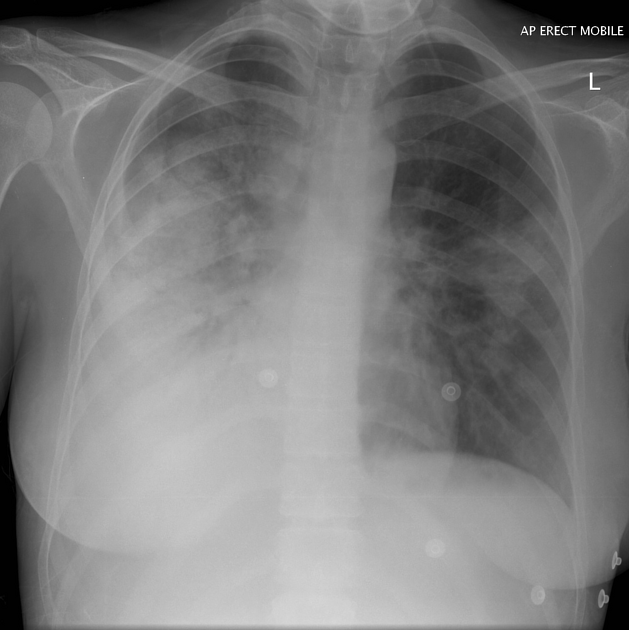

In [ ]:
import base64
from io import BytesIO
import requests
import torch
from PIL import Image
from IPython.display import display
from langchain_core.messages import HumanMessage
from uqlm import BlackBoxUQ

# 1. Define the target image URL for the chest radiograph
image_url = "https://prod-images-static.radiopaedia.org/images/554213/27e6e725de1f349479fd214944aaf0d32523ec38f111107b6f347a3530e4b4ff_big_gallery.jpeg"

# 2. Fetch, stream, and open the image for vision-language processing
response = requests.get(image_url, stream=True)
image_bytes = response.content
image_input = Image.open(BytesIO(image_bytes)).convert("RGB")

# 3. Encode image content to base64 for data URI formatting
encoded_image = base64.b64encode(image_bytes).decode("utf-8")

# 4. Render and display the image within the workspace environment
display(image_input)

# 5. Define the clinical prompt for analysis
input_text = "Analyze the provided chest radiograph and report any focal consolidation, pneumothorax, or pleural effusion:"

# 6. Construct a single multimodal prompt using HumanMessage with the correct data URI structure
prompt = [
    HumanMessage(
        content=[
            {"type": "text", "text": input_text},
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{encoded_image}"
                }
            }
        ]
    )
]

In [ ]:
# 5. Initialize Black-Box UQ with the noncontradiction scorer
bbuq = BlackBoxUQ(
    llm=llm,
    scorers=["noncontradiction"],
    system_prompt="Answer as concisely as possible.",
    use_best=False
)

# 6. Execute asynchronous generation and scoring on the multimodal prompt
result = await bbuq.generate_and_score(prompts=[prompt], num_responses=5)

# 7. Convert and inspect results in a DataFrame
df_results = result.to_df()
print(df_results)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

Output()

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

                                              prompt  \
0  [content=[{'type': 'text', 'text': 'Analyze th...   

                                            response  \
0  I'm unable to analyze images directly. For a p...   

                                   sampled_responses  noncontradiction  
0  [I'm unable to analyze images directly. For ac...          0.999547  


---
### **📌 Claim-Level UQ**

#### **📝 Long-Text & Claim-Level Scorers (`LongTextUQ`)**

While standard black-box and white-box scorers evaluate uncertainty globally at the sequence level, long-form generation requires granular verification. The **`LongTextUQ`** class handles this by automatically decomposing model responses into atomic, independent claims and computing uncertainty metrics locally for each component using consistency and similarity scorers. 🔍

##### **`LongTextUQ` Initialization API Reference**

| Parameter | Type | Default | Description |
| --- | --- | --- | --- |
| **`llm`** | `BaseChatModel` | `None` | A LangChain chat model used for generation and claim decomposition. |
| **`granularity`** | `str` | `"claim"` | Granularity level for decomposition. Must be either `"claim"` or `"sentence"`. |
| **`scorers`** | `List[str]` | `["entailment"]` | Subset of available scorers (`"entailment"`, `"noncontradiction"`, `"contrasted_entailment"`, `"bert_score"`, `"cosine_sim"`). |
| **`mode`** | `str` | `"unit_response"` | Scoring style (`"unit_response"` or `"matched_unit"`). |
| **`aggregation`** | `str` | `"mean"` | Method to aggregate claim-level scores to the response level (`'min'` or `'mean'`). |
| **`response_refinement`** | `bool` | `False` | Whether to remove low-confidence claims and reconstruct the response via uncertainty-aware decoding. |
| **`claim_decomposition_prompt`** | `str` | `"zhang_2025"` | Prompt template for claim splitting (`"zhang_2025"`, `"farquhar_2024"`, `"mohri_2024"`, `"jiang_2024"`). |
| **`device`** | `str | torch.device` | `"cpu"` | Computational device for evaluation models. |


<br>

**Supported UQ Technicques:** It support the following UQ-Technicques: `entailment`, `noncontradiction`, `contrasted_entailment`, `bert_score`, `cosine_sim`




In [ ]:
import asyncio
from uqlm import LongTextUQ

# 1. Parameter configuration
prompts = [
    "Provide a concise clinical case summary for a 45-year-old patient with hypertension.",
]

technique_name = "entailment"
result_key = technique_name
num_responses = 3

# 2. Initialization
lt_uq = LongTextUQ(
    llm=llm,
    granularity="claim",
    scorers=[technique_name]
)

Output()

[{'prompt': 'Provide a concise clinical case summary for a 45-year-old patient with hypertension.', 'claim_payload': {'library': 'uqlm', 'estimator_name': 'entailment', 'granularity': 'claim', 'input_prompt': 'Provide a concise clinical case summary for a 45-year-old patient with hypertension.', 'generated_text': '**Clinical Case Summary:**\n\n**Patient:** 45-year-old male\n\n**Chief Complaint:** Routine check-up; elevated blood pressure readings.\n\n**History of Present Illness:** The patient presents for a routine examination. He reports no significant symptoms but mentions occasional headaches. Blood pressure readings taken during the visit are consistently elevated, ranging from 150/95 mmHg to 160/100 mmHg. He has no history of cardiovascular disease.\n\n**Past Medical History:** \n- Hypertension diagnosed 2 years ago, not consistently managed.\n- No known chronic illnesses.\n- No prior hospitalizations or surgeries.\n\n**Medications:** \n- Occasional over-the-counter NSAIDs for he

#### **🔍 Fine-Grained UQ Claim Extraction and Management**

The structured management and extraction of data points following asynchronous execution involve three key steps:

1. **Result Serialization**: Calling `to_dict()` converts the `uqlm` output object into a navigable data structure.

2. **Metadata Extraction**: Complete textual response pools (`responses`) and the detailed atomic claims matrix (`claims_data`) are isolated.

3. **Fine-Grained Mapping (`claim`)**: Each claim is mapped to its respective uncertainty score and encapsulated into a standardized payload for tracking or clinical review.

In [ ]:
# 3. Asynchronous execution of LongTextUQ for claim-level decomposition and scoring
uqlm_result = await lt_uq.generate_and_score(prompts=prompts, num_responses=num_responses)

# 4. Conversion and retrieval of data pools
res_dict = uqlm_result.to_dict()
responses_pool = res_dict["data"].get("responses", [])
claims_data = res_dict["data"].get("claims_data", [])

# 5. Inline processing for claim-level granularity using cosine similarity
output_results = []

for idx, current_prompt in enumerate(prompts):
    generated_text = responses_pool[idx] if idx < len(responses_pool) else None

    # --- Granularity Management: CLAIM ---
    formatted_claims = []
    if idx < len(claims_data) and claims_data[idx]:
        formatted_claims = [
            {
                "claim_text": c.get("claim"),
                "score": c.get(result_key)
            }
            for c in claims_data[idx]
        ]

    payload_claim = {
        "library": "uqlm",
        "estimator_name": technique_name,
        "granularity": "claim",
        "input_prompt": current_prompt,
        "generated_text": generated_text,
        "uncertainty_score": formatted_claims,
        "raw_uq_result": uqlm_result,
    }

    # Append the extracted claim-level results for the current prompt
    output_results.append({
        "prompt": current_prompt,
        "claim_payload": payload_claim
    }

# Display final claim-level results
print(output_results)


---
## **🧰 UQ Toolbox & Utilities**

In this section, we explore the custom **UQ Toolbox**—a collection of wrapper functions, utility modules, and orchestration tools designed to streamline, standardize, and extend standard uncertainty quantification workflows. Rather than writing repetitive boilerplate code, this toolbox provides clean, high-level abstractions to simplify pipeline execution, component registration, and response evaluation.

### **📁 Module Architecture & Subdivisions**

To ensure clean separation of concerns and maintainable, production-grade code, the toolbox is organized into the following modular components:

* **⚙️ `core/`**: Contains the foundational execution engines and evaluation logic:
  * 🔄> `pipeline.py`: Defines the end-to-end execution structure for running UQ evaluations.
  * 🔍 `response_evaluator.py`: Implements metrics, scoring logic, and evaluation wrappers for model outputs.
  * 🧠 `uq_engine.py`: Powers the underlying uncertainty calculation loops and backend calls.


* **📥 `data/`**: Provides data handling utilities:
  * 📊 `data_loader.py`: Handles dataset ingestion, preprocessing, and formatting tailored for UQ tasks.


* **🎛️ `managers/`**: Handles centralized orchestration and model management:
  * 🔌 `llama_cpp_manager.py`: Manages integration and execution workflows for `llama.cpp` backends.
  * 🛠️ `model_manager.py`: Coordinates model lifecycles, configuration, and low-level dependencies.


* **📌 Root Package Files**:
  * 🗂️ `registry.py`: Acts as a central component registry for dynamic lookup, configuration, and instantiation of custom scorers and models.

**Install Our Toolbox**

In [2]:

!git clone https://github.com/miky-alt/UQ-Text-Mining.git
%cd UQ-Text-Mining


%pip install -e .

from uq_toolbox.data import prepare_dataset
print("📦 UQ Toolbox importato con successo!")

/content
Cloning into 'UQ-Text-Mining'...
remote: Enumerating objects: 268, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 268 (delta 65), reused 44 (delta 32), pack-reused 163 (from 1)
Receiving objects: 100% (268/268), 21.22 MiB | 13.00 MiB/s, done.
Resolving deltas: 100% (136/136), done.
/content/UQ-Text-Mining
Processing ./.
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> from file:///content/UQ-Text-Mining

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


ModuleNotFoundError: No module named 'uq_toolbox'

### **📥 Data Loader**

`prepare_dataset` is a universal utility function designed to overcome the structural fragmentation of Hugging Face Hub datasets. It normalizes disparate schemas, complex nested keys, and mixed text-image modalities into a consistent format, generating clean, leakage-free data splits essential for Uncertainty Quantification (UQ) and calibration pipelines.

#### ⚙️ Parameter Reference

| Parameter | Type | Default | Description |
| --- | --- | --- | --- |
| **`path`** | `str` | *Required* | The Hugging Face Hub repository path or identifier for the target dataset. |
| **`question_col`** | `Union[str, List[str]]` | *Required* | Column name(s) or nested key paths used to extract question text. |
| **`answer_col`** | `str` | *Required* | Column name containing the ground-truth target answers. |
| **`name`** | `Optional[str]` | `None` | Specific configuration or subset name for the Hugging Face dataset. |
| **`context_col`** | `Optional[str]` | `None` | Optional column containing contextual metadata to prepend to the question text. |
| **`image_col`** | `Optional[str]` | `None` | Optional column containing image data for multimodal workflows. |
| **`split`** | `str` | `"train"` | The dataset split to load from the hub. |
| **`max_samples`** | `Optional[int]` | `None` | Deterministic downsampling cap to limit total records processed. |
| **`test_size`** | `float` | `0.33` | Proportion of the standardized dataset allocated to the holdout test pool. |
| **`random_state`** | `int` | `42` | Random seed ensuring reproducibility across sampling and splitting. |

<br>

#### 💡 Usage Example

In [ ]:
from uq_toolbox.data import prepare_dataset

# Inload, normalize, and split any dataset from the Hugging Face Hub (e.g., SQuAD)
train_pool, test_pool = prepare_dataset(
    path="squad",
    question_col="question",
    answer_col="answers",
    context_col="context",
    max_samples=1000,  # Caps samples for rapid pipeline prototyping
    test_size=0.2     # 20% holdout test set for evaluation
)

print(f"Calibration Pool (Train): {len(train_pool)} rows")
print(f"Holdout Pool (Test): {len(test_pool)} rows")

---

### **🎛️ Managers**



#### **🛠️ Model Manager (`UQModelManager`)**

* **What it is:** A centralized class designed to load, register, and manage models across distinct UQ frameworks (`lm_polygraph` and LangChain-based `uqlm`).
* **Why it was made:** To eliminate multi-framework fragmentation by providing a unified interface that transparently handles operational modes (white-box vs. black-box), memory quantization, multimodal support, and GPU memory cleanup.

##### **Description of Main Methods**

1. **`__init__(default_polygraph_mode, default_uqlm_mode)`**: Initializes internal registries and default operational box-modes for both frameworks.
2. **`list_active_models()`**: Prints an inspection summary of all models currently active in memory, showing their aliases and box configurations.
3. **`add_polygraph_model(...)`**: Loads and registers local or API-based models for `lm_polygraph`, applying BitsAndBytes quantization or visual white-box wrappers as needed.
4. **`add_uqlm_model(...)`**: Configures and registers LangChain-based LLMs across providers (OpenAI, Google, Anthropic, local LlamaCpp via `LlamaCppManager`), enforcing box restrictions where necessary.
5. **`remove_models(aliases)`**: Performs memory cleanup, triggering garbage collection and flushing GPU VRAM via `torch.cuda.empty_cache()` to prevent memory leaks.



#### **🏭 Factory Utility Function (`initialize_uq_models`)**

* **What it is:** A factory-pattern wrapper function designed to streamline the instantiation of `UQModelManager`.
* **Why it was made:** To enable the rapid bulk-loading of multi-model, multi-framework experimental environments using clean, declarative configuration dictionaries.


##### **`initialize_uq_models` Parameter Reference**

| Parameter | Type | Default | Description |
| --- | --- | --- | --- |
| **`polygraph_models`** | `Optional[Union[str, dict]]` | `None` | Model ID string or declarative config dictionary for Polygraph models. |
| **`polygraph_is_multimodal`** | `bool` | `False` | Enables multimodal visual white-box support for Polygraph models. |
| **`uqlm_models`** | `Optional[dict]` | `None` | Dictionary mapping aliases to LangChain-based UQLM models. |
| **`p_mode`** | `Optional[str]` | `None` | Default operational mode (`"black"` or `"white"`) for Polygraph. |
| **`u_mode`** | `Optional[str]` | `None` | Default operational mode (`"black"` or `"white"`) for UQLM. |
| **`quant_choice`** | `Optional[str]` | `None` | Memory quantization strategy (`"4bit"`, `"8bit"`, or `"none"`). |
| **`temperature`** | `float` | `0.7` | Sampling temperature for text generation. |
| **`max_tokens`** | `int` | `256` | Maximum new tokens allowed in outputs. |
| **`ollama_url`** | `str` | `"http://localhost:11434"` | Endpoint URL for local Ollama instances. |
| **`auto_install`** | `bool` | `False` | Automatically handle missing dependencies or binaries. |
| **`polygraph_kwargs`** | `Optional[dict]` | `None` | Global extra keyword arguments for Polygraph model loaders. |
| **`uqlm_kwargs`** | `Optional[dict]` | `None` | Global extra keyword arguments for UQLM model loaders. |

In [ ]:
from uq_toolbox.managers import initialize_uq_models

# Quick initialization of a unified multi-framework environment
uq_engine = initialize_uq_models(
    polygraph_models={"default": "Qwen/Qwen2.5-1.5B-Instruct"},
    uqlm_models={"openai_alias": {"provider": "openai", "model_id": "gpt-4o-mini"}},
    p_mode="white",
    u_mode="black"
)

# Inspect active models in the registries
uq_engine.list_active_models()







### **🗂️ Central Catalog and Query Engine (`UQ_REGISTRY` & `list_uq_techniques`)**

* **What they are:**
  * **`UQ_REGISTRY`**: A central tree-structured dictionary cataloging all available uncertainty quantification metrics, categorized by backend library (`lm_polygraph` and `uqlm`) and mapping their core metadata.
  * **`list_uq_techniques`**: A query utility function used to search, filter, and print the catalog in a readable tabular format.


* **Why they were made:**
  * To empower users to search and discover the exact techniques that fit their specific constraints (hardware limits, compute overhead, model access mode, and text granularity) using filters.
  
  * To serve as an underlying runtime lookup map for `evaluate_uncertainty` to automatically resolve string technique names into the correct backend estimator classes.



#### 🔍 `list_uq_techniques` Parameter Reference

| Parameter | Type | Description |
| --- | --- | --- |
| **`library`** | `UQLibrary` | Filters metrics by specific backend (`UQLibrary.POLYGRAPH` or `UQLibrary.UQLM`). |
| **`mode`** | `str` | Filters based on required model access level (e.g., `"white"` or `"black"`). |
| **`granularity`** | `str` | Filters by analysis resolution level (e.g., `"sequence"`, `"claim"`, `"token"`). |
| **`category`** | `str` | Filters by taxonomic classification (e.g., *Information-based*, *Sample diversity*, *Reflexive*). |
| **`compute`** | `str` | Filters by estimated computational overhead (e.g., `"Low"`, `"Medium"`, `"High"`). |
| **`need_training`** | `bool` | Filters based on whether a preliminary training phase is required. |

In [ ]:
# Display only low-compute white-box techniques
list_uq_techniques(mode="white", compute="Low")


---
### **⚙️ Core**

#### **🧠 UQ Engine**

#### `evaluate_uncertainty`: Unified UQ Entry Point

* **What it is:** A central core utility function that wraps and standardizes uncertainty calculation across both backend frameworks (`lm_polygraph` and `uqlm`).
* **Why it was made:** To provide a single cohesive function that enables:
  * **Cross-library execution:** Run techniques from both `lm_polygraph` and `uqlm` across all available granularities (sequence, token, claim).
  * **Multimodal support:** Process visual data and images natively alongside text prompts.
  * **Error management:** Automatically catch and handle configuration mismatches, such as
    * Attempting to apply a white-box technique to a black-box model
    * Specifying an unsupported granularity for a given technique.

  * **Alias-based model selection:** Target specific model backbones effortlessly using the `model_alias` parameter.

<br>

##### 📋 `evaluate_uncertainty` Parameter Reference

| Parameter | Type | Description |
| --- | --- | --- |
| **`prompt`** | `str` or `List[str]` | The target input string (or list of strings) to evaluate. Supports tags and visual contexts (`<image>`). |
| **`technique_name`** | `str` | The identifier of the registered UQ metric inside the central registry (`UQ_REGISTRY`). |
| **`granularity`** | `str` | The analysis resolution level (e.g., `'sequence'`, `'claim'`, `'token'`). |
| **`uq_context`** | `Any` | The unified context holding loaded models (`polygraph_models` or `langchain_llms`). |
| **`image_path`** | `Optional[str]` | Optional local path to a target reference image for multimodal tasks. |
| **`image_base64`** | `Optional[str]` | Optional base64 representation of the image to include in the payload. |
| **`model_alias`** | `str` | The specific model backbone alias to query. Defaults to `"default"`. |
| **`**kwargs`** | `Any` | Additional keyword arguments to configure specific estimator hyperparameters. |

In [ ]:
import asyncio

# Execution of sequence-level uncertainty evaluation with a medical domain prompt
result = await evaluate_uncertainty(
    prompt="A 54-year-old patient presents with acute chest pain radiating to the left arm and diaphoresis. What are the primary differential diagnoses?",
    technique_name="uqlm_sequence_entropy",
    granularity="sequence",
    uq_context=uq_engine_instance,
    model_alias="default"
)

print("Generated Medical Response:", result["generated_text"])
print("Uncertainty Score:", result["uncertainty_score"])

#### **🔍 Response Evaluators**

* **What they are:** A module featuring an abstract base contract (`BaseResponseEvaluator`) and concrete off-the-shelf evaluators (`SubstringMatchEvaluator` for deterministic rule-based checks and `LLMGraderEvaluator` for model-assisted semantic grading). They function as response evaluators to determine whether the model's generated text is genuinely reflected by or aligned with the ground-truth reference.

* **Why they were made:** To measure the factual correctness, alignment, and quality of generated outputs against ground-truth references using uniform asynchronous evaluation strategies across different pipelines.

* **How to use them:** Inherit from `BaseResponseEvaluator` to implement custom asynchronous `__call__` methods, or instantiate pre-built graders like `SubstringMatchEvaluator` to grade generated outputs against your benchmark data.

<br>

##### **`__call__` Method Signature Reference**

| Parameter | Type | Description |
| --- | --- | --- |
| **`prompt`** | `str` | The input prompt or query provided to the language model. |
| **`generated_text`** | `str` | The response output generated by the model. |
| **`ground_truth`** | `str` | The reference answer used to evaluate factual accuracy and alignment. |
| **`Returns`** | `float` | A numerical score representing the evaluation result (e.g., `1.0` for correct/aligned, `0.0` for mismatched). |

In [ ]:
from uq_toolbox.evaluation import BaseResponseEvaluator

class CustomClinicalEvaluator(BaseResponseEvaluator):
    """Custom evaluator checking for critical keyword inclusion."""
    async def __call__(self, prompt: str, generated_text: str, ground_truth: str) -> float:
        # Implement custom domain-specific scoring logic
        is_valid = ground_truth.strip().lower() in generated_text.strip().lower()
        return 1.0 if is_valid else 0.0

---
### **🔄 Pipelines: Batch Evaluation & Dataset Processing**

#### **📊 `compute_dataset_uq_scores` (Sequential Dataset Evaluation)**

* **What it is:** A sequential orchestration utility that ingests dataset sources, automatically parses elements, iterates through samples and target techniques, executes uncertainty evaluation, and archives metrics.
* **Why it was made:** To scale uncertainty and quality evaluation seamlessly across full datasets or iterables while automating data preparation, multi-modality handling, and response grading.

##### **Parameters Table**

| Parameter | Type | Description |
| --- | --- | --- |
| **`dataset`** | `pd.DataFrame` or `Iterable` | The dataset source containing prompts, questions, answers, or images. |
| **`uq_techniques`** | `List[str]` | List of registered UQ technique names to evaluate. |
| **`uq_context`** | `Any` | The unified context holding loaded models. |
| **`evaluator`** | `BaseResponseEvaluator` | Concrete evaluator instance for grading responses. |
| **`granularity`** | `str` | Analysis resolution level (defaults to `"sequence"`). |
| **`tech_kwargs_registry`** | `Optional[Dict[str, Dict[str, Any]]]` | Technique-specific hyperparameters dictionary. |
| **`**global_uq_kwargs`** | `Any` | Global keyword arguments passed to all evaluations. |

* **Return Description:** A nested dictionary mapping each technique to lists of `scores`, `qualities`, `prompts`, `responses`, `questions`, and `ground_truths`.


In [ ]:
import pandas as pd
from uq_toolbox.pipelines import compute_dataset_uq_scores
from uq_toolbox.evaluation import ExactMatchEvaluator

# Load dataset and initialize evaluator and context
dataset = pd.read_csv("medical_benchmark.csv")
evaluator = ExactMatchEvaluator()

# Execute pipeline across selected UQ techniques
results_registry = await compute_dataset_uq_scores(
    dataset=dataset,
    uq_techniques=["uqlm_sequence_entropy", "polygraph_perplexity"],
    uq_context=uq_engine_instance,
    evaluator=evaluator,
    granularity="sequence"
)

print("Processed techniques:", list(results_registry.keys()))



#### **📦 `compute_batch_uqlm_scores` (Batch Processing Pipeline)**

* **What it is:** A high-throughput chunked processing utility that divides large collections of prompt and reference lists into manageable chunks to execute batch uncertainty evaluation.
* **Why it was made:** To optimize performance and memory management when evaluating large-scale collections of prompts and reference answers concurrently in batches.

##### **Parameters Table**

| Parameter | Type | Description |
| --- | --- | --- |
| **`prompts`** | `List[str]` | List of input text prompts. |
| **`reference_answers`** | `List[str]` | Corresponding ground-truth reference answers. |
| **`uq_techniques`** | `List[str]` | List of registered UQ technique names to evaluate. |
| **`granularity`** | `str` | Analysis resolution level. |
| **`uq_context`** | `Any` | The unified context holding loaded models. |
| **`evaluator`** | `BaseResponseEvaluator` | Concrete evaluator instance for grading responses. |
| **`model_alias`** | `str` | Target backbone model alias (defaults to `"default"`). |
| **`batch_size`** | `int` | Batch size for chunked processing (defaults to `16`). |
| **`**kwargs`** | `Any` | Additional configuration arguments for the UQ engine. |

* **Return Value Type:** `Dict[str, Dict[str, Any]]`
* **Return Description:** A nested dictionary matching the uniform metrics archive structure.

###

In [ ]:
import pandas as pd
from uq_toolbox.pipelines import compute_batch_uqlm_scores
from uq_toolbox.evaluation import ExactMatchEvaluator

# Load dataset and extract prompt and reference lists
df = pd.read_csv("medical_benchmark.csv")
prompts = df["question"].tolist()
reference_answers = df["answer"].tolist()

# Initialize evaluator and context
evaluator = ExactMatchEvaluator()

# Execute high-throughput batch pipeline across selected UQ techniques
results_registry = await compute_batch_uqlm_scores(
    prompts=prompts,
    reference_answers=reference_answers,
    uq_techniques=["uqlm_sequence_entropy", "polygraph_perplexity"],
    granularity="sequence",
    uq_context=uq_engine_instance,
    evaluator=evaluator,
    batch_size=16
)

print("Processed techniques:", list(results_registry.keys()))

##